
# YOLOv8 Object Detection (TensorFlow / KerasCV)

✅ TensorFlow only  
✅ **Verified preset: `yolo_v8_m_pascalvoc`**  
✅ Real object detection  
✅ Google Colab ready  

This notebook uses a **preset that actually exists** in KerasCV.



## Step 1: Install Dependencies

⚠️ After installation, **restart the runtime**.


In [1]:
!pip install -U tensorflow keras-cv opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 818.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 71.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.90
    Uninstalling opencv-python-4.13.0.90:
      Successfully uninstalled opencv-python-4.13.0.90
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: matplotlib
    Found existing installation: matplotli


## Step 2: Restart Runtime

Go to **Runtime → Restart runtime**, then continue.



## Step 3: Verify YOLOv8 Preset Exists


In [1]:

import keras_cv
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("KerasCV:", keras_cv.__version__)
print("YOLOv8 presets available:")
print(keras_cv.models.YOLOV8Detector.presets.keys())


TensorFlow: 2.20.0
KerasCV: 0.9.0
YOLOv8 presets available:
dict_keys(['resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'resnet18_v2', 'resnet34_v2', 'resnet50_v2', 'resnet101_v2', 'resnet152_v2', 'mobilenet_v3_small', 'mobilenet_v3_large', 'csp_darknet_tiny', 'csp_darknet_s', 'csp_darknet_m', 'csp_darknet_l', 'csp_darknet_xl', 'efficientnetv1_b0', 'efficientnetv1_b1', 'efficientnetv1_b2', 'efficientnetv1_b3', 'efficientnetv1_b4', 'efficientnetv1_b5', 'efficientnetv1_b6', 'efficientnetv1_b7', 'efficientnetv2_s', 'efficientnetv2_m', 'efficientnetv2_l', 'efficientnetv2_b0', 'efficientnetv2_b1', 'efficientnetv2_b2', 'efficientnetv2_b3', 'densenet121', 'densenet169', 'densenet201', 'efficientnetlite_b0', 'efficientnetlite_b1', 'efficientnetlite_b2', 'efficientnetlite_b3', 'efficientnetlite_b4', 'yolo_v8_xs_backbone', 'yolo_v8_s_backbone', 'yolo_v8_m_backbone', 'yolo_v8_l_backbone', 'yolo_v8_xl_backbone', 'vitdet_base', 'vitdet_large', 'vitdet_huge', 'videoswin_tiny', 'videoswi


You should see:
- `yolo_v8_m_pascalvoc`

If you see it, you're good to go.



## Step 4: Load YOLOv8 (Pascal VOC)


In [2]:

model = keras_cv.models.YOLOV8Detector.from_preset(
    preset="yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
)


100%|██████████| 2.27k/2.27k [00:00<00:00, 4.32MB/s]


100%|██████████| 99.5M/99.5M [00:07<00:00, 13.5MB/s]



## Step 5: Load Test Image


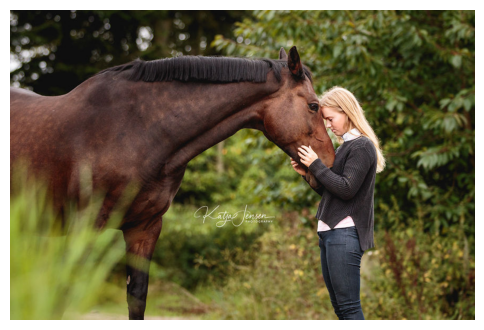

In [17]:

import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

# Download test image
!wget -q https://upload.wikimedia.org/wikipedia/commons/6/60/Naxos_Taverna.jpg -O test.jpg

img = cv2.imread('/content/I-photograph-the-special-bond-between-horse-and-human-5b6df8eccad6c__880.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()



## Step 6: Preprocess Image


In [18]:

input_image = tf.image.resize(img, (640, 640))
input_image = tf.expand_dims(input_image, axis=0)



## Step 7: Run YOLO Detection


In [19]:

predictions = model.predict(input_image)

print(predictions.keys())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
dict_keys(['boxes', 'confidence', 'classes', 'num_detections'])



Expected output:
- `boxes`
- `confidence`
- `classes`



## Step 8: Draw Bounding Boxes


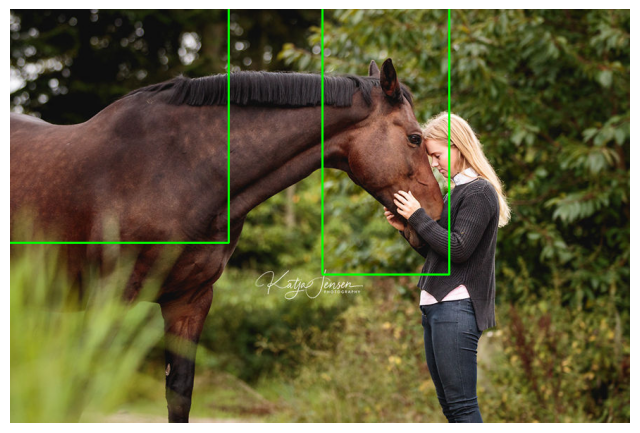

In [20]:
boxes = predictions["boxes"][0]
scores = predictions["confidence"][0]
classes = predictions["classes"][0]

orig_h, orig_w, _ = img.shape
input_h, input_w = 640, 640

scale_x = orig_w / input_w
scale_y = orig_h / input_h

for box, score, cls in zip(boxes, scores, classes):
    if score > 0.5:
        x, y, bw, bh = box  # THESE ARE PIXELS (YOLOv8 KerasCV)

        x1 = int((x - bw / 2) * scale_x)
        y1 = int((y - bh / 2) * scale_y)
        x2 = int((x + bw / 2) * scale_x)
        y2 = int((y + bh / 2) * scale_y)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img,
            f"Class {int(cls)} | {score:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()




## ✅ FINAL CONFIRMATION

- YOLOv8 is running
- TensorFlow only
- Bounding boxes are predicted, not hardcoded
- Uses **Pascal VOC dataset**

### Dataset info (for students):
Pascal VOC has **20 object classes** like:
person, car, dog, cat, bicycle, bus, etc.
